In [ ]:
import json
import re
import math
import time
from copy import deepcopy
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Callable, Optional

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

import matplotlib.pyplot as plt

# 1) GRPO - Group Relative Policy Optimization

![](https://miro.medium.com/1*O_CSxm5jvLR1lYolEIWCvg.png)

**Understanding GRPO and RLVR — The Engine Behind Modern Reasoning Models**

---

In January 2025, DeepSeek released R1, an open-source reasoning model that matched
the performance of OpenAI's o1. The paper revealed that the secret was surprisingly
simple: take a pretrained LLM, let it generate many attempts at solving a problem,
tell it which attempts were correct, and update the model to favor the correct ones.
No human-labeled reasoning traces. No reward model. No critic network.

The algorithm that made this possible is **GRPO** (Group Relative Policy Optimization).
The training strategy is **RLVR** (Reinforcement Learning with Verifiable Rewards).
Together, they are now the standard recipe for building reasoning models, tool-calling
agents, and code generation systems.

---

**How GRPO differs from DPO**

In our DPO notebook, we trained on **pre-collected** preference pairs.
The model never generated anything during training — it only learned from static data.

GRPO flips this: the model **generates its own training data** during training.
For each prompt, it samples multiple candidate responses, scores them,
and updates its weights to favor the better responses.

| | DPO | GRPO |
|---|-----|------|
| Training data | Pre-collected pairs | Generated on-the-fly |
| Reference model | Required (frozen copy) | Optional (KL penalty) |
| Reward signal | Implicit in preference pairs | Explicit reward function |
| Can exceed training data quality? | No (bounded by data) | Yes (explores new solutions) |
| Models in memory | 2 (policy + reference) | 1–2 (policy + optional reference) |
| Best for | Alignment, style | Reasoning, code, tool calling |

# 2) Configuration

**What is GRPO?**


GRPO is a reinforcement learning algorithm designed specifically for language models.
It is a simplified descendant of PPO (Proximal Policy Optimization), the algorithm
that powered the original ChatGPT. GRPO makes two key simplifications:

* The first is removing the **critic model**. In PPO, a separate neural network
(the "critic") estimates how good each state is. This critic is as large as the
policy model itself, doubling GPU memory requirements and adding training complexity.
GRPO replaces the critic with a simple idea: generate a *group* of responses
to the same prompt, score them, and use the group statistics (mean and standard
deviation) as the baseline. Responses above the group average get reinforced,
responses below get discouraged. No separate model needed.

* The second is removing the **reward model**. Traditional RLHF trains a neural
network on human preference data to predict which responses are "better." This
reward model is expensive to build and can be gamed. GRPO (when combined with
RLVR) replaces it with a simple rule-based function: did the model get the right
answer? This is only possible when correctness can be verified automatically —
hence the name "verifiable rewards."

The result is that GRPO needs only **one model in memory** (the policy), compared
to PPO which needs four (policy, critic, reward model, reference model). This
makes it practical to train large models on available hardware.

**How GRPO and RLVR work together**

GRPO is the optimizer. RLVR provides the reward signal. Together, the training loop is:

```
For each batch of prompts (e.g., math problems):
    1. Generate G candidate responses per prompt         ← the "group"
    2. Score each response: correct (1.0) or wrong (0.0) ← RLVR
    3. Normalize scores within each group (z-score)       ← advantages
    4. Update the model to increase probability of        ← GRPO
       above-average responses and decrease
       below-average ones
```

The model learns through trial and error. It generates many attempts, finds out which
ones work, and adjusts itself to produce more of the working solutions. Over time,
it discovers reasoning strategies — chain-of-thought, self-verification, backtracking —
that nobody explicitly taught it. These are emergent behaviors that arise from the
optimization pressure of getting the right answer.

In [ ]:
@dataclass
class GRPOConfig:
    """All hyperparameters for GRPO training in one place.

    Grouped by function so you can see what controls what.
    """
    # --- Generation ---
    num_generations: int = 4         # num_samples: responses sampled per prompt
    max_new_tokens: int = 256        # output_len: Maximum response length
    temperature: float = 1.0         # Sampling temperature (higher = more diverse)
    top_p: float = 0.95              # Nucleus sampling threshold

    # --- Policy optimization ---
    epsilon: float = 0.2             # Clipping range (lower bound: 1 - epsilon)
    epsilon_high: float = None       # Asymmetric upper clip (DAPO). None = same as epsilon
    mu: int = 1                      # Policy updates per generation batch
    max_grad_norm: float = 1.0       # Gradient clipping

    # --- KL penalty ---
    beta: float = 0.0                # KL coefficient. 0 = no KL. DeepSeek-R1 used 0.001
    use_reference_model: bool = False # Whether to load a frozen reference model

    # --- Loss variant ---
    loss_type: str = "dapo"          # "grpo", "dr_grpo", or "dapo"

    # --- Training ---
    lr: float = 1e-5                 # Learning rate
    batch_size: int = 2              # batch_num: Prompts per step
    grad_accum_steps: int = 2        # Gradient accumulation steps
    num_epochs: int = 2              # Training epochs
    warmup_steps: int = 5            # LR warmup steps

    # --- Filtering (DAPO) ---
    filter_dead_groups: bool = True  # Skip groups with zero advantage variance
    mask_truncated: bool = True      # Exclude truncated (no EOS) responses from loss

    # --- Monitoring ---
    log_interval: int = 1            # Print metrics every N steps


@dataclass
class GenerationResult:
    """Holds generated responses with metadata for a single prompt."""
    prompt: str
    responses: List[str]

    # Store response token sequences
    # List of (output_len) tensors
    response_ids: List[torch.Tensor]

    # Tracking for sequences that hit max_len
    is_truncated: List[bool]

    # Store the input prompt tokens
    # (input_len) tensor
    prompt_ids: torch.Tensor

In [ ]:
MODEL_NAME = "Qwen/Qwen2-0.5B-Instruct"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16).to(device)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Model: {MODEL_NAME}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {device}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model: Qwen/Qwen2-0.5B-Instruct
Parameters: 494,032,768
Device: cuda


# 3) Batch Generation with Truncation Tracking


Generation is the most expensive part of GRPO — for each prompt, we run
full autoregressive inference G times. Two important details:

**Batched generation**: Instead of generating one response at a time,
we batch all G generations for a prompt together. This better utilizes
the GPU and can be 3–4x faster than sequential generation.

**Truncation tracking**: When a response reaches `max_new_tokens` without
producing an EOS token, it was cut off mid-thought. The DAPO paper shows
that including these truncated responses in the loss hurts training —
the model gets penalized for not finishing, when it simply ran out of tokens.
So we track which responses were truncated and optionally exclude them.

In [ ]:
@torch.no_grad()
def generate_for_prompt(
    model,
    tokenizer,
    prompt: str,
    num_generations: int = 4,
    max_new_tokens: int = 256,
    temperature: float = 1.0,
    top_p: float = 0.95,
) -> GenerationResult:
    """Generate G responses for a single prompt with truncation tracking."""
    # Tokenize the input prompt
    # (1, input_len)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    prompt_len = inputs["input_ids"].shape[1]
    prompt_ids = inputs["input_ids"][0]

    # Expand prompt tokens for batched generation
    # Input: (1, input_len)
    # Output: (batch_num, input_len)
    batch_num = num_generations
    batched_input_ids = inputs["input_ids"].expand(batch_num, -1)
    batched_attention = inputs["attention_mask"].expand(batch_num, -1)

    # Generate responses autoregressively
    # Input: (batch_num, input_len)
    # Output: (batch_num, input_len + output_len)
    outputs = model.generate(
        input_ids=batched_input_ids,
        attention_mask=batched_attention,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id,
    )

    responses = []
    response_ids_list = []
    is_truncated = []

    # Process each generated sequence in the batch
    for i in range(batch_num):
        # Slice to keep only the newly generated response tokens
        # Input: (input_len + output_len)
        # Output: (output_len)
        resp_ids = outputs[i, prompt_len:]

        # Filter out padding tokens at the end
        non_pad = (resp_ids != tokenizer.pad_token_id)
        if non_pad.any():
            last_real = non_pad.nonzero()[-1].item() + 1
            resp_ids = resp_ids[:last_real]

        # Determine if the generation was cut off by the length limit
        ended_with_eos = (
            resp_ids.numel() > 0 and resp_ids[-1].item() == tokenizer.eos_token_id
        )
        truncated = not ended_with_eos and resp_ids.numel() >= max_new_tokens

        # Decode token IDs back to human-readable text
        response_text = tokenizer.decode(resp_ids, skip_special_tokens=True)
        responses.append(response_text)
        response_ids_list.append(resp_ids)
        is_truncated.append(truncated)

    return GenerationResult(
        prompt=prompt,
        responses=responses,
        response_ids=response_ids_list,
        is_truncated=is_truncated,
        prompt_ids=prompt_ids,
    )

# === Quick test ===
model.eval()
test_result = generate_for_prompt(model, tokenizer, "What is 2 + 3?", num_generations=3, max_new_tokens=64)
print(f"Prompt: {test_result.prompt}")
for i, (r, t) in enumerate(zip(test_result.responses, test_result.is_truncated)):
    print(f"  Response {i} (truncated={t}): {r[:80]}...")

Prompt: What is 2 + 3?
  Response 0 (truncated=True):  It seems like there are so many different ways to approach this problem. Let's ...
  Response 1 (truncated=True):   The answer can be written out as a fraction, a mixed number, or a decimal.
Usi...
  Response 2 (truncated=True):  This has always confused me. How do you calculate this?
$$
2 + 3 = 
1 \hspace{0...


# 4) Reward Function

**What is RLVR?**

RLVR is not an algorithm — it is a **training strategy**. It means: instead of
using human preferences or a learned reward model, use automated verification
to score the model's outputs.

The key insight is that many important tasks have objectively checkable answers:

- **Math**: Run the answer through a symbolic verifier. Is $2 + 3 = 5$? Yes or no.
- **Code**: Execute the generated code against unit tests. Does it pass?
- **Tool calling**: Parse the JSON output. Is it valid? Did it call the right function with correct arguments?
- **Structured output**: Does the output match the required schema?

For all of these, a simple Python function can replace thousands of hours of human labeling.
The reward is binary (correct or not), fast to compute, and perfectly consistent.

The limitation is that RLVR only works where you can define "correct." Creative writing,
open-ended conversation, and subjective quality still need human preferences (DPO, RLHF).
But for reasoning, coding, and tool use — the tasks driving the most value in 2025–2026 —
RLVR is sufficient and far cheaper.

The reward function is where GRPO connects to the task.
Same algorithm, different reward → different capability.

A good reward function should be:

- **Binary or near-binary** — 1.0 for correct, 0.0 for wrong.
  Continuous rewards add noise. Use at most 2–3 discrete levels.
- **Composable** — break complex tasks into sub-rewards.
  For example: format reward (0.1) + correctness reward (0.9).
- **Strict on format** — if the model doesn't follow the expected output
  format, give 0 reward. This teaches formatting alongside correctness.
- **Fast** — reward runs for every response in every group at every step.

## 4.1 Math Reward

In [ ]:
def extract_boxed_answer(text: str) -> Optional[str]:
    """Extract answer from \\boxed{...} format.

    Handles nested braces by counting brace depth.
    """
    # Find \boxed{ start
    idx = text.find("\\boxed{")
    if idx == -1:
        return None

    start = idx + len("\\boxed{")
    depth = 1
    i = start
    while i < len(text) and depth > 0:
        if text[i] == "{":
            depth += 1
        elif text[i] == "}":
            depth -= 1
        i += 1

    if depth == 0:
        return text[start:i-1].strip()
    return None


def extract_answer_tag(text: str) -> Optional[str]:
    """Extract answer from <answer>...</answer> tags."""
    match = re.search(r"<answer>(.*?)</answer>", text, re.DOTALL)
    return match.group(1).strip() if match else None


def normalize_answer(answer: str) -> str:
    """Normalize an answer string for comparison.

    Handles common equivalences: whitespace, trailing zeros,
    fraction representations, etc.
    """
    answer = answer.strip().lower()
    # Remove trailing .0 for integers: "42.0" -> "42"
    if re.match(r"^-?\d+\.0+$", answer):
        answer = answer.split(".")[0]
    return answer


def math_reward(response: str, ground_truth: str) -> float:
    """Reward function for math reasoning.

    Reward structure:
        1.0 — correct answer in proper format (\\boxed{} or <answer>)
        0.1 — proper format but wrong answer (encourages formatting)
        0.0 — no extractable answer

    The 0.1 partial reward for formatting is important early in training.
    Without it, the model has no gradient signal to learn the output format,
    which makes it harder to learn correctness later.
    """
    # Try extraction methods in order of preference
    extracted = extract_boxed_answer(response)
    if extracted is None:
        extracted = extract_answer_tag(response)

    if extracted is None:
        return 0.0

    # Normalize and compare
    extracted_norm = normalize_answer(extracted)
    truth_norm = normalize_answer(str(ground_truth))

    if extracted_norm == truth_norm:
        return 1.0

    # Try numeric comparison for "3.0" == "3", "1/2" == "0.5", etc.
    try:
        if abs(float(extracted_norm) - float(truth_norm)) < 1e-6:
            return 1.0
    except (ValueError, TypeError):
        pass

    return 0.1  # Right format, wrong answer

In [ ]:
# Tests
print("Math reward tests:")
tests = [
    ("The answer is \\boxed{42}", "42", "correct boxed"),
    ("So we get \\boxed{43}", "42", "wrong answer, right format"),
    ("<answer>42</answer>", "42", "correct tag"),
    ("I think it is 42", "42", "no format"),
    ("\\boxed{3.0}", "3", "numeric equivalence"),
    ("\\boxed{\\frac{1}{2}}", "\\frac{1}{2}", "nested braces"),
]
for response, truth, desc in tests:
    print(f"  {desc}: {math_reward(response, truth)}")

Math reward tests:
  correct boxed: 1.0
  wrong answer, right format: 0.1
  correct tag: 1.0
  no format: 0.0
  numeric equivalence: 1.0
  nested braces: 1.0


## 4.2 Tool calling reward

In [ ]:
def extract_json_from_response(text: str) -> Optional[dict]:
    """Extract and parse JSON from a model response.

    Handles common cases:
    - Raw JSON: {"name": "get_weather", ...}
    - Markdown code block: ```json\n{...}\n```
    - JSON embedded in text: "I'll call the tool: {...}"
    """
    # Try markdown code block first
    md_match = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, re.DOTALL)
    if md_match:
        try:
            return json.loads(md_match.group(1))
        except json.JSONDecodeError:
            pass

    # Try to find any JSON object (greedy match for nested braces)
    brace_start = text.find("{")
    if brace_start == -1:
        return None

    depth = 0
    i = brace_start
    while i < len(text):
        if text[i] == "{":
            depth += 1
        elif text[i] == "}":
            depth -= 1
            if depth == 0:
                try:
                    return json.loads(text[brace_start:i+1])
                except json.JSONDecodeError:
                    return None
        i += 1

    return None


def tool_call_reward(response: str, expected: dict) -> float:
    """Reward function for tool calling.

    Reward structure:
        1.0 — correct function name AND all arguments match
        0.5 — correct function name, partially correct arguments
        0.3 — correct function name, wrong arguments
        0.1 — valid JSON with "name" field, wrong function
        0.0 — no valid JSON tool call found

    Expected format:
        {"name": "get_weather", "arguments": {"city": "Tokyo"}}
    """
    parsed = extract_json_from_response(response)
    if parsed is None:
        return 0.0

    # Must have "name" field to be a tool call
    if "name" not in parsed:
        return 0.0

    # Check function name
    if parsed["name"] != expected["name"]:
        return 0.1  # Valid tool call format, wrong function

    # Check arguments
    expected_args = expected.get("arguments", {})
    parsed_args = parsed.get("arguments", {})

    if not expected_args and not parsed_args:
        return 1.0  # No args expected, none provided

    if parsed_args == expected_args:
        return 1.0  # Perfect match

    # Partial credit: count matching arguments
    if expected_args:
        matches = sum(1 for k, v in expected_args.items() if parsed_args.get(k) == v)
        match_ratio = matches / len(expected_args)
        if match_ratio > 0:
            return 0.3 + 0.2 * match_ratio  # 0.3 to 0.5

    return 0.3  # Right function, wrong args

In [ ]:
print("\nTool calling reward tests:")
expected = {"name": "get_weather", "arguments": {"city": "Tokyo"}}
tests = [
    ('{"name": "get_weather", "arguments": {"city": "Tokyo"}}', "perfect match"),
    ('{"name": "get_weather", "arguments": {"city": "London"}}', "wrong arg value"),
    ('{"name": "get_weather", "arguments": {}}', "missing args"),
    ('{"name": "search", "arguments": {"query": "weather"}}', "wrong function"),
    ('```json\n{"name": "get_weather", "arguments": {"city": "Tokyo"}}\n```', "markdown block"),
    ("I think you should check the weather", "no JSON"),
]
for response, desc in tests:
    print(f"  {desc}: {tool_call_reward(response, expected)}")


Tool calling reward tests:
  perfect match: 1.0
  wrong arg value: 0.3
  missing args: 0.3
  wrong function: 0.1
  markdown block: 1.0
  no JSON: 0.0


# 5) Advantage Computation

For a group of $G$ responses to the same prompt with rewards $[r_1, \ldots, r_G]$:

$$\hat{A}_i = \frac{r_i - \text{mean}(r_1, \ldots, r_G)}{\text{std}(r_1, \ldots, r_G) + \epsilon}$$

This z-score normalization makes advantages scale-invariant.
Responses better than the group average get positive advantages
(reinforce them), worse ones get negative advantages (discourage them).

**Dead groups**: When all rewards are identical (e.g., all correct or all wrong),
$\text{std} = 0$ and all advantages are $\approx 0$. There is no training signal.
DAPO recommends filtering these out rather than wasting compute on them.

**Why this matters**: In early training, many groups will be all-wrong (no model
can solve the problem yet). In late training, many will be all-correct. Both
cases produce no gradient. The useful training signal comes from groups where
the model gets some right and some wrong — those are at the frontier of its ability.

In [ ]:
def compute_advantages(
    rewards: torch.Tensor,
    mask: torch.Tensor = None,
    eps: float = 1e-8,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Compute group-normalized advantages with dead group detection.

    Input:
        rewards: (batch_num, num_samples) — reward scores per response
        mask:    (batch_num, num_samples) — optional mask (0 = exclude this response, e.g. truncated)
        eps:     numerical stability for std division

    Output:
        advantages: (batch_num, num_samples) — z-score normalized
        alive_mask: (batch_num,) — True for groups with variance (useful training signal)
    """

    if mask is not None:
        # Mask rewards to ignore invalid completions
        # (batch_num, num_samples)
        masked_rewards = rewards * mask

        # Calculate valid counts per group
        # Output: (batch_num, 1)
        count = mask.sum(dim=1, keepdim=True).clamp_min(1)

        # Compute group mean reward
        # (batch_num, 1)
        mean = masked_rewards.sum(dim=1, keepdim=True) / count

        # Compute group standard deviation
        # (batch_num, 1)
        diff_sq = ((rewards - mean) * mask) ** 2
        var = diff_sq.sum(dim=1, keepdim=True) / count.clamp_min(2)
        std = var.sqrt()
    else:
        # Compute unmasked mean and std
        # (batch_num, 1)
        mean = rewards.mean(dim=1, keepdim=True)
        std = rewards.std(dim=1, keepdim=True)

    # Apply z-score normalization
    # (batch_num, num_samples)
    advantages = (rewards - mean) / (std + eps)

    # Zero out advantages for masked responses
    # (batch_num, num_samples)
    if mask is not None:
        advantages = advantages * mask

    # Detect groups with non-zero variance for training signal
    # (batch_num,)
    alive_mask = (std.squeeze(1) > eps)

    return advantages, alive_mask

In [ ]:
# Tests
print("Advantage computation tests:\n")

test_rewards = torch.tensor([
    [1.0, 0.0, 1.0, 0.0],   # Mixed — good signal
    [1.0, 1.0, 1.0, 0.0],   # Mostly correct — some signal
    [0.0, 0.0, 0.0, 0.0],   # All wrong — DEAD group
    [1.0, 1.0, 1.0, 1.0],   # All correct — DEAD group
])

advs, alive = compute_advantages(test_rewards)
for i in range(4):
    status = "ALIVE" if alive[i] else "DEAD (no signal)"
    print(f"  Group {i}: rewards={test_rewards[i].tolist()} → advantages={advs[i].tolist()}")
    print(f"           {status}")

# Test with truncation mask
print("\nWith truncation mask (response 2 in group 0 was truncated):")
trunc_mask = torch.tensor([
    [1.0, 1.0, 0.0, 1.0],   # Response 2 excluded (truncated)
    [1.0, 1.0, 1.0, 1.0],   # All included
])
trunc_rewards = torch.tensor([
    [1.0, 0.0, 1.0, 0.0],
    [1.0, 0.0, 1.0, 0.0],
])
advs_masked, _ = compute_advantages(trunc_rewards, mask=trunc_mask)
print(f"  Without mask: {compute_advantages(trunc_rewards)[0][0].tolist()}")
print(f"  With mask:    {advs_masked[0].tolist()} (response 2 advantage forced to 0)")

Advantage computation tests:

  Group 0: rewards=[1.0, 0.0, 1.0, 0.0] → advantages=[0.866025447845459, -0.866025447845459, 0.866025447845459, -0.866025447845459]
           ALIVE
  Group 1: rewards=[1.0, 1.0, 1.0, 0.0] → advantages=[0.5, 0.5, 0.5, -1.5]
           ALIVE
  Group 2: rewards=[0.0, 0.0, 0.0, 0.0] → advantages=[0.0, 0.0, 0.0, 0.0]
           DEAD (no signal)
  Group 3: rewards=[1.0, 1.0, 1.0, 1.0] → advantages=[0.0, 0.0, 0.0, 0.0]
           DEAD (no signal)

With truncation mask (response 2 in group 0 was truncated):
  Without mask: [0.866025447845459, -0.866025447845459, 0.866025447845459, -0.866025447845459]
  With mask:    [1.4142135381698608, -0.7071068286895752, 0.0, -0.7071068286895752] (response 2 advantage forced to 0)


# 6) Log-Probability Computation


We need per-token log-probabilities for two purposes:

1. **Old log-probs** ($\log \pi_{\text{old}}$): computed once after generation, frozen
2. **Current log-probs** ($\log \pi_\theta$): computed during each policy update, with gradients

The ratio between them is the importance weight:
$r_t = \exp(\log \pi_\theta - \log \pi_{\text{old}})$

**Critical detail: mask alignment**

Because of causal LM's next-token prediction, logits at position $t$
predict the token at position $t+1$. This means:
- `logits[:, :-1, :]` aligns with `input_ids[:, 1:]`
- The response mask must also be shifted by 1 to match

Getting this wrong means the loss includes prompt tokens or misses
response tokens — a subtle bug that degrades training.

In [ ]:
def compute_log_probs(
    model,
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    response_mask: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Compute per-token log-probabilities and entropy for the response portion.

    Returns both log-probs (for the loss) and entropy (for monitoring).

    Input:
        input_ids:      (batch_num, seq_len)
        attention_mask:  (batch_num, seq_len)
        response_mask:   (batch_num, seq_len) — 1 for response tokens, 0 for prompt/pad

    Output:
        log_probs: (batch_num, seq_len-1) — per-token log-prob, masked to response only
        entropy:   (batch_num,) — per-sequence average entropy over response tokens
    """
    # Perform forward pass to get logits
    # (batch_num, seq_len, vocab_size)
    logits = model(input_ids=input_ids, attention_mask=attention_mask).logits

    # Shift for next-token prediction alignment
    # logits[:, t, :] predicts token at position t+1
    # (batch_num, seq_len-1, vocab_size)
    shifted_logits = logits[:, :-1, :]

    # Shift targets to align with predicted logits
    # (batch_num, seq_len-1)
    shifted_targets = input_ids[:, 1:]

    # Shift response mask to align with predicted logits
    # (batch_num, seq_len-1)
    shifted_mask = response_mask[:, 1:]

    # Compute log-softmax over vocabulary
    # (batch_num, seq_len-1, vocab_size)
    log_probs_all = F.log_softmax(shifted_logits, dim=-1)

    # Gather log-probabilities for the actual tokens provided in targets
    # Input: (batch_num, seq_len-1, vocab_size)
    # Output: (batch_num, seq_len-1)
    per_token_logps = torch.gather(
        log_probs_all, dim=2, index=shifted_targets.unsqueeze(2)
    ).squeeze(2)

    # Mask log-probabilities to isolate response tokens
    # (batch_num, seq_len-1)
    per_token_logps = per_token_logps * shifted_mask

    # Compute probabilities for entropy calculation
    # (batch_num, seq_len-1, vocab_size)
    probs = F.softmax(shifted_logits, dim=-1)

    # Compute token-level entropy (negative sum of p * log(p))
    # (batch_num, seq_len-1)
    # if probs is saturated at one token, the rest will be 0, etropy will be low
    token_entropy = -(probs * log_probs_all).sum(dim=-1)

    # Mask entropy to isolate response tokens
    # (batch_num, seq_len-1)
    masked_entropy = token_entropy * shifted_mask

    # Calculate lengths of generated responses for averaging
    # Input: (batch_num, seq_len-1)
    # Output: (batch_num,)
    response_lengths = shifted_mask.sum(dim=1).clamp_min(1)

    # Compute average entropy per response sequence
    # Input: (batch_num, seq_len-1)
    # Output: (batch_num,)
    seq_entropy = masked_entropy.sum(dim=1) / response_lengths

    return per_token_logps, seq_entropy

# 7) Loss Function

**The GRPO Loss — What Each Part Does**

$$\mathcal{L} = -\frac{1}{N} \sum_{i,t} \min\!\big(r_t \hat{A}_i,\; \text{clip}(r_t, 1{-}\epsilon, 1{+}\epsilon) \hat{A}_i\big) + \beta \cdot D_{\text{KL}}$$

**Ratio** $r_t = \exp(\text{current_logps} - \text{old_logps})$ — how much did
the model change at this token? If $r_t = 1.0$, no change. Above 1.0, token became
more likely. Below 1.0, less likely.

**Clipping** — caps the ratio to $[0.8, 1.2]$ (with $\epsilon = 0.2$). This prevents
the model from changing too much in one step, keeping training stable.

**Advantage** $\hat{A}_i$ — positive for good responses (reinforce), negative for
bad ones (discourage). Multiplied by the ratio so the gradient pushes in the right direction.

**min()** — takes the more conservative of clipped vs unclipped. If the model already
moved enough, stop pushing.

**KL penalty** (optional, $\beta$) — penalizes drifting too far from the original model.
Set $\beta = 0$ to disable (DAPO recommends this since clipping is enough).

In [ ]:
def grpo_loss(
    current_logps: torch.Tensor,
    old_logps: torch.Tensor,
    advantages: torch.Tensor,
    response_mask: torch.Tensor,
    *,
    epsilon: float = 0.2,
    epsilon_high: float = None,
    ref_logps: torch.Tensor = None,
    beta: float = 0.0,
    loss_type: str = "dapo",
    max_completion_length: int = None,
    entropy: torch.Tensor = None,
) -> Tuple[torch.Tensor, dict]:
    """GRPO clipped surrogate loss with all production-relevant features."""

    # Compute importance ratio between current and old policy
    # Output: (batch_num, seq_len)
    ratio = torch.exp(current_logps - old_logps)

    # Expand advantages to match token-level ratio dimensions
    # ratio is at token level while advantage is at sentence level.
    # Input: (batch_num,)
    # Output: (batch_num, seq_len)
    token_advs = advantages.unsqueeze(1).expand_as(ratio)

    # Calculate clipping bounds for the surrogate objective
    lower = 1.0 - epsilon
    upper = 1.0 + (epsilon_high if epsilon_high is not None else epsilon)

    # Apply clipping to the importance ratio
    # (batch_num, seq_len)
    clipped_ratio = torch.clamp(ratio, lower, upper)

    # Compute the clipped surrogate objective
    # apply the advantage (sentence level) to all token from same sentence
    # Output: (batch_num, seq_len)
    unclipped = ratio * token_advs
    clipped = clipped_ratio * token_advs
    surrogate = torch.min(unclipped, clipped)

    # Apply response mask to isolate relevant tokens
    # (batch_num, seq_len)
    masked_surrogate = surrogate * response_mask

    # Aggregate loss based on the specified variant
    if loss_type == "grpo":
        # Original GRPO: per-sequence average, then batch average
        # Input: (batch_num, seq_len) → Output: ()
        per_seq = masked_surrogate.sum(dim=1) / response_mask.sum(dim=1).clamp_min(1)
        loss = -per_seq.mean()

    elif loss_type == "dr_grpo":
        # Dr-GRPO: divide by max length to remove length bias
        # Input: (batch_num, seq_len) → Output: ()
        L = max_completion_length or response_mask.size(1)
        B = masked_surrogate.size(0)
        loss = -masked_surrogate.sum() / (B * L)

    elif loss_type == "dapo":
        # DAPO: global average over all active tokens in the batch
        # Input: (batch_num, seq_len) → Output: ()
        loss = -masked_surrogate.sum() / response_mask.sum().clamp_min(1)

    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")

    # Calculate KL penalty to constrain policy drift
    kl = torch.tensor(0.0, device=loss.device)
    if ref_logps is not None and beta > 0:
        # Schulman's estimator for token-level KL
        # (batch_num, seq_len)
        log_ratio = ref_logps - current_logps
        kl_per_token = torch.exp(log_ratio) - log_ratio - 1.0
        # Average KL over masked response tokens
        kl = (kl_per_token * response_mask).sum() / response_mask.sum().clamp_min(1)
        loss = loss + beta * kl

    # Compute training metrics for logging
    with torch.no_grad():
        clip_frac = ((ratio - 1.0).abs() > epsilon).float()
        clip_frac = (clip_frac * response_mask).sum() / response_mask.sum().clamp_min(1)
        approx_kl = 0.5 * ((current_logps - old_logps) ** 2 * response_mask).sum() / response_mask.sum().clamp_min(1)

    metrics = {
        "loss": loss.item(),
        "clip_fraction": clip_frac.item(),
        "kl": kl.item(),
        "approx_kl": approx_kl.item(),
        "ratio_mean": (ratio * response_mask).sum().item() / response_mask.sum().clamp_min(1).item(),
    }
    if entropy is not None:
        metrics["entropy"] = entropy.mean().item()

    return loss, metrics

# 8) Training

## 8.1 Pipeline

**GRPO training flow (one batch)**

Assume: B=2 prompts, G=4 generations each, seq_len varies

---

**Phase 1 — Generate and score (done once per batch)**
```
1. Generate G responses per prompt
   → B prompts × G generations = 8 text responses total
   → Shape conceptually: (B=2, G=4) = 8 text strings
   → These are FROZEN for the rest of this batch

2. Score each response with reward function
   → rewards: (B=2, G=4)
   → Example: [[1.0, 0.0, 1.0, 0.1],
                [0.0, 0.0, 1.0, 0.0]]

3. Filter dead groups + mask truncated
   → trunc_mask: (B=2, G=4) — 0 for truncated, 1 otherwise
   → alive_mask: (B=2,) — False if all rewards identical in group

4. Compute advantages
   → advantages: (B=2, G=4) — z-score normalized rewards
   → Example: [[+0.9, -1.1, +0.9, -0.7],
                [-0.6, -0.6, +1.8, -0.6]]

5. Tokenize all 8 prompt+response pairs
   → Flatten (B=2, G=4) → (B*G=8) sequences
   → input_ids:      (8, seq_len)  ← the G samples live here as token IDs
   → attention_mask:  (8, seq_len)
   → response_mask:   (8, seq_len)
   → flat_advantages: (8,)         ← one advantage per response

6. Compute OLD log-probs (frozen, no gradient)
   → Feed input_ids (8, seq_len) through model
   → old_logps: (8, seq_len-1)    ← probability of each token in G samples
   → This is the ANCHOR — never recomputed
```

**Phase 2 — Learn from G samples (repeat mu times)**
```
┌──────────────────────────────────────────────────────────────┐
│  For mu = 1, 2, 3 ...                                       │
│  (same input_ids, same advantages, same old_logps)           │
│                                                              │
│  7a. Feed the SAME input_ids (8, seq_len) through model      │
│      → current_logps: (8, seq_len-1)  ← WITH gradient       │
│      → entropy: (8,)                  ← for monitoring       │
│      → These CHANGE each iteration because weights changed   │
│                                                              │
│  7b. Compute ratio at every token                            │
│      → ratio = exp(current_logps - old_logps)                │
│      → ratio: (8, seq_len-1)                                 │
│      → First iteration: ratio ≈ 1.0 everywhere              │
│      → Later iterations: ratio drifts as weights change      │
│                                                              │
│  7c. Multiply ratio × advantage at every token               │
│      → flat_advantages (8,) → expand to (8, seq_len-1)      │
│      → Each token in a response gets the SAME advantage      │
│        (the whole response was good or bad, not per-token)   │
│      → surrogate: (8, seq_len-1)                             │
│                                                              │
│  7d. Clip ratio to [0.8, 1.2], take min(clipped, unclipped)  │
│      → loss: scalar                                          │
│                                                              │
│  7e. Backprop                                                │
│      → Gradient flows through current_logps (8, seq_len-1)   │
│      → old_logps: no gradient (detached)                     │
│      → flat_advantages: no gradient (just a coefficient)     │
│      → Weights update → next mu iteration sees different     │
│        current_logps for the SAME input_ids                  │
└──────────────────────────────────────────────────────────────┘
```

**Phase 3 — Apply update**
```
8. Clip gradients → optimizer.step()
   → Weights updated
   → Go back to Phase 1 with NEXT batch of prompts
   → Generate FRESH responses with the improved model
```

---

**Where the G samples appear at each step:**

| Step | G samples represented as | Shape |
|------|--------------------------|-------|
| 1. Generate | Raw text strings | (B=2, G=4) text |
| 2. Reward | Text → compared to ground truth | (B=2, G=4) float |
| 4. Advantages | Normalized rewards | (B=2, G=4) → flatten → (8,) |
| 5. Tokenize | Text → token IDs | (B*G=8, seq_len) |
| 6. Old log-probs | Token IDs → model → log-probs | (8, seq_len-1) |
| 7a. Current log-probs | **Same** token IDs → model → log-probs | (8, seq_len-1) |
| 7b. Ratio | current / old per token | (8, seq_len-1) |
| 7c. Loss | ratio × advantage per token | (8, seq_len-1) → scalar |

The G samples start as text (step 1), become token IDs (step 5),
and stay as token IDs for every mu iteration (steps 7a–7e).
The model re-reads the same 8 sequences each time — it just
assigns different probabilities because its weights changed.

In [ ]:
def build_prompt_response_batch(
    tokenizer,
    gen_results: List[GenerationResult],
    config: GRPOConfig,
) -> Dict[str, torch.Tensor]:
    """Tokenize all prompt+response pairs from generation results into a padded batch.

    Produces a batch of batch_num*num_samples sequences.

    Output keys:
        input_ids:      (batch_num*num_samples, seq_len)
        attention_mask:  (batch_num*num_samples, seq_len)
        response_mask:   (batch_num*num_samples, seq_len) — 1 for response tokens only
        truncation_mask: (batch_num*num_samples,) — 0 for truncated responses, 1 otherwise
    """
    all_input_ids = []
    all_attn_masks = []
    all_resp_masks = []
    truncation_flags = []

    # Iterate through generation results to extract tokenized sequences
    for gen_result in gen_results:
        # Input: (input_len)
        prompt_ids = gen_result.prompt_ids

        for j, resp_ids in enumerate(gen_result.response_ids):
            # Concatenate prompt + response tokens
            # Output: (seq_len)
            full_ids = torch.cat([prompt_ids, resp_ids])
            prompt_len = prompt_ids.size(0)
            full_len = full_ids.size(0)

            # Create attention and response masks
            # Output: (seq_len)
            attn_mask = torch.ones(full_len, dtype=torch.long)
            resp_mask = torch.zeros(full_len, dtype=torch.long)
            resp_mask[prompt_len:] = 1

            all_input_ids.append(full_ids)
            all_attn_masks.append(attn_mask)
            all_resp_masks.append(resp_mask)

            # Track truncation status for filtering
            truncation_flags.append(0.0 if gen_result.is_truncated[j] else 1.0)

    # Determine padding length for the batch
    max_len = max(ids.size(0) for ids in all_input_ids)
    pad_id = tokenizer.pad_token_id

    padded_ids, padded_attn, padded_resp = [], [], []
    # Apply zero-padding to align sequence lengths
    # (seq_len)
    for ids, attn, resp in zip(all_input_ids, all_attn_masks, all_resp_masks):
        pad_size = max_len - ids.size(0)
        padded_ids.append(F.pad(ids, (0, pad_size), value=pad_id))
        padded_attn.append(F.pad(attn, (0, pad_size), value=0))
        padded_resp.append(F.pad(resp, (0, pad_size), value=0))

    # Stack into final batch tensors
    # Output: (batch_num * num_samples, max_len)
    return {
        "input_ids": torch.stack(padded_ids),
        "attention_mask": torch.stack(padded_attn),
        "response_mask": torch.stack(padded_resp),
        "truncation_mask": torch.tensor(truncation_flags),
    }


def get_lr(step: int, total_steps: int, config: GRPOConfig) -> float:
    """Cosine learning rate schedule with linear warmup."""
    if step < config.warmup_steps:
        # Linear warmup phase
        return config.lr * (step + 1) / config.warmup_steps
    else:
        # Cosine decay phase
        progress = (step - config.warmup_steps) / max(1, total_steps - config.warmup_steps)
        return config.lr * 0.5 * (1.0 + math.cos(math.pi * progress))

def set_lr(optimizer, lr):
    # Update learning rate for all parameter groups
    for pg in optimizer.param_groups:
        pg["lr"] = lr

In [ ]:
def train_grpo(
    model,
    tokenizer,
    dataset: Dataset,
    reward_fn: Callable,
    config: GRPOConfig,
    ground_truth_key: str = "answer",
) -> List[dict]:
    """Complete GRPO training loop with all production features.

    Args:
        model:            The policy model to train
        tokenizer:        Tokenizer for the model
        dataset:          Dataset with "prompt" and ground_truth_key fields
        reward_fn:        Callable(response: str, ground_truth) -> float
        config:           GRPOConfig with all hyperparameters
        ground_truth_key: Key in dataset for the ground truth answer

    Returns:
        List of per-step metrics dictionaries
    """

    # Initialize reference model for KL penalty if configured
    ref_model = None
    if config.use_reference_model and config.beta > 0:
        ref_model = deepcopy(model)
        ref_model.eval()
        for p in ref_model.parameters():
            p.requires_grad = False
        print("Reference model loaded (frozen copy for KL penalty)")

    # Setup optimizer and training tracking variables
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    total_steps = config.num_epochs * len(dataset) // config.batch_size
    all_metrics = []
    global_step = 0

    for epoch in range(config.num_epochs):
        # Shuffle dataset indices for each epoch
        indices = torch.randperm(len(dataset)).tolist()

        for batch_start in range(0, len(dataset), config.batch_size):
            batch_indices = indices[batch_start:batch_start + config.batch_size]
            if len(batch_indices) < config.batch_size:
                continue

            # Extract prompts and ground truth answers from batch samples
            batch_samples = [dataset[i] for i in batch_indices]
            prompts = [s["prompt"] for s in batch_samples]
            ground_truths = [s[ground_truth_key] for s in batch_samples]
            batch_num = len(prompts)
            num_samples = config.num_generations

            # Update learning rate based on current step
            current_lr = get_lr(global_step, total_steps, config)
            set_lr(optimizer, current_lr)

            # Generate num_samples responses for each prompt in the batch
            model.eval()
            gen_results = []
            for prompt in prompts:
                gr = generate_for_prompt(
                    model, tokenizer, prompt,
                    num_generations=num_samples,
                    max_new_tokens=config.max_new_tokens,
                    temperature=config.temperature,
                    top_p=config.top_p,
                )
                gen_results.append(gr)

            # Compute verifiable rewards for generated outputs
            # Output: (batch_num, num_samples)
            rewards = torch.zeros(batch_num, num_samples)
            for i in range(batch_num):
                for j in range(num_samples):
                    rewards[i, j] = reward_fn(gen_results[i].responses[j], ground_truths[i])

            # Create mask for responses that were truncated by length limits
            # Output: (batch_num, num_samples)
            trunc_mask = torch.ones(batch_num, num_samples)
            if config.mask_truncated:
                for i in range(batch_num):
                    for j in range(num_samples):
                        if gen_results[i].is_truncated[j]:
                            trunc_mask[i, j] = 0.0

            # Compute group-relative advantages normalized by mean/std
            # Input: (batch_num, num_samples)
            # Output: (batch_num, num_samples), (batch_num,)
            advantages, alive_mask = compute_advantages(
                rewards, mask=trunc_mask if config.mask_truncated else None
            )

            # Skip batches where all generation attempts lack variance
            if config.filter_dead_groups:
                alive_count = alive_mask.sum().item()
                if alive_count == 0:
                    if global_step % config.log_interval == 0:
                        print(f"  Step {global_step}: ALL GROUPS DEAD — skipping (reward_mean={rewards.mean():.2f})")
                    global_step += 1
                    continue

            # Tokenize prompt-response pairs into a padded batch
            # Output: Dictionary containing (batch_num * num_samples, seq_len) tensors
            batch_tensors = build_prompt_response_batch(tokenizer, gen_results, config)
            batch_tensors = {k: v.to(device) for k, v in batch_tensors.items()}

            # Flatten advantages and masks for token-level loss calculation
            # Input: (batch_num, num_samples)
            # Output: (batch_num * num_samples,)
            flat_advantages = advantages.reshape(-1).to(device)
            flat_alive = alive_mask.unsqueeze(1).expand(batch_num, num_samples).reshape(-1).to(device)
            combined_trunc = batch_tensors["truncation_mask"].to(device)

            # Zero out advantages for truncated or dead groups
            # Output: (batch_num * num_samples,)
            flat_advantages = flat_advantages * flat_alive.float() * combined_trunc

            # Compute baseline log-probabilities using the initial policy
            # Output: (batch_num * num_samples, seq_len-1)
            model.eval()
            with torch.no_grad():
                old_logps, _ = compute_log_probs(
                    model,
                    batch_tensors["input_ids"],
                    batch_tensors["attention_mask"],
                    batch_tensors["response_mask"],
                )

                # Compute log-probs for reference model to calculate KL divergence
                ref_logps = None
                if ref_model is not None and config.beta > 0:
                    ref_logps, _ = compute_log_probs(
                        ref_model,
                        batch_tensors["input_ids"],
                        batch_tensors["attention_mask"],
                        batch_tensors["response_mask"],
                    )

            # Update policy model weights over multiple iterations
            model.train()
            shifted_resp_mask = batch_tensors["response_mask"][:, 1:]

            for mu_iter in range(config.mu):
                # Get current log-probs and entropy for surrogate loss
                # Input: (batch_num * num_samples, seq_len)
                # Output: (batch_num * num_samples, seq_len-1), (batch_num * num_samples,)
                current_logps, entropy = compute_log_probs(
                    model,
                    batch_tensors["input_ids"],
                    batch_tensors["attention_mask"],
                    batch_tensors["response_mask"],
                )

                # Compute the GRPO clipped surrogate objective loss
                # Input: (batch_num * num_samples, seq_len-1), (batch_num * num_samples,)
                # Output: scalar loss, metrics
                loss, metrics = grpo_loss(
                    current_logps=current_logps,
                    old_logps=old_logps,
                    advantages=flat_advantages,
                    response_mask=shifted_resp_mask,
                    epsilon=config.epsilon,
                    epsilon_high=config.epsilon_high,
                    ref_logps=ref_logps,
                    beta=config.beta,
                    loss_type=config.loss_type,
                    max_completion_length=config.max_new_tokens,
                    entropy=entropy,
                )

                # Accumulate gradients over steps
                scaled_loss = loss / config.grad_accum_steps
                scaled_loss.backward()

            # Perform gradient clipping and optimizer step
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            # Log step metrics and statistics
            metrics["reward_mean"] = rewards.mean().item()
            metrics["reward_std"] = rewards.std().item()
            metrics["frac_correct"] = (rewards == 1.0).float().mean().item()
            metrics["alive_groups"] = alive_mask.sum().item()
            metrics["total_groups"] = batch_num
            metrics["trunc_frac" ] = 1.0 - combined_trunc.mean().item()
            metrics["lr"] = current_lr
            metrics["epoch"] = epoch
            metrics["step"] = global_step

            all_metrics.append(metrics)

            if global_step % config.log_interval == 0:
                print(
                    f"  Epoch {epoch} Step {global_step}: "
                    f"loss={metrics['loss']:.4f}  "
                    f"reward={metrics['reward_mean']:.2f}  "
                    f"correct={metrics['frac_correct']:.0%}  "
                    f"clip={metrics['clip_fraction']:.2%}  "
                    f"entropy={metrics.get('entropy', 0):.2f}  "
                    f"alive={metrics['alive_groups']}/{metrics['total_groups']}  "
                    f"lr={current_lr:.2e}"
                )

            global_step += 1

    return all_metrics

In [ ]:
def plot_training_metrics(metrics: List[dict], title: str = "GRPO Training"):
    """Plot key training metrics from the metrics log."""
    steps = [m["step"] for m in metrics]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(title, fontsize=14)

    # Reward mean
    axes[0, 0].plot(steps, [m["reward_mean"] for m in metrics], color="green")
    axes[0, 0].set_ylabel("Reward Mean")
    axes[0, 0].set_title("Average Reward")
    axes[0, 0].grid(True, alpha=0.3)

    # Fraction correct
    axes[0, 1].plot(steps, [m["frac_correct"] for m in metrics], color="blue")
    axes[0, 1].set_ylabel("Fraction Correct")
    axes[0, 1].set_title("Accuracy (reward=1.0)")
    axes[0, 1].grid(True, alpha=0.3)

    # Loss
    axes[0, 2].plot(steps, [m["loss"] for m in metrics], color="red")
    axes[0, 2].set_ylabel("Loss")
    axes[0, 2].set_title("GRPO Loss")
    axes[0, 2].grid(True, alpha=0.3)

    # Entropy
    if "entropy" in metrics[0]:
        axes[1, 0].plot(steps, [m.get("entropy", 0) for m in metrics], color="orange")
        axes[1, 0].set_ylabel("Entropy (nats)")
        axes[1, 0].set_title("Policy Entropy (low = collapse risk)")
        axes[1, 0].grid(True, alpha=0.3)

    # Clip fraction
    axes[1, 1].plot(steps, [m["clip_fraction"] for m in metrics], color="purple")
    axes[1, 1].set_ylabel("Clip Fraction")
    axes[1, 1].set_title("Clipping Fraction")
    axes[1, 1].grid(True, alpha=0.3)

    # Alive groups
    axes[1, 2].plot(steps, [m["alive_groups"] / m["total_groups"] for m in metrics], color="teal")
    axes[1, 2].set_ylabel("Alive Ratio")
    axes[1, 2].set_title("Alive Groups (non-dead)")
    axes[1, 2].grid(True, alpha=0.3)

    for ax in axes.flat:
        ax.set_xlabel("Step")

    plt.tight_layout()
    plt.show()

## 8.2 Training on Math Reasoning

We now run GRPO on math problems. The model will learn to:

1. Reason through the problem step by step
2. Format its final answer in $boxed$
3. Get the answer correct

Watch these metrics:
- **reward_mean** should increase as the model learns
- **frac_correct** tracks how often the model gets the exact right answer
- **entropy** should stay reasonably high (if it drops to near 0, the model is collapsing)
- **alive_groups** shows how many groups have a useful training signal.
  If this drops to 0, training stalls.

In early steps, most rewards will be 0 (the model can't solve the problems yet).
The 0.1 partial reward for correct formatting helps bootstrap the learning signal.


In [ ]:
class SimpleDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]

math_config = GRPOConfig(
    num_generations=4,
    max_new_tokens=128,
    temperature=0.8,
    top_p=0.95,
    epsilon=0.2,
    mu=1,
    beta=0.0,
    use_reference_model=False,
    loss_type="dapo",
    lr=1e-5,
    batch_size=2,
    grad_accum_steps=1,
    num_epochs=2,
    warmup_steps=3,
    filter_dead_groups=True,
    mask_truncated=True,
)

MATH_SAMPLES = [
    {"prompt": "What is 15 + 27? Show your work and put your final answer in \\boxed{}.", "answer": "42"},
    {"prompt": "What is 8 * 7? Show your work and put your final answer in \\boxed{}.", "answer": "56"},
    {"prompt": "What is 100 - 37? Show your work and put your final answer in \\boxed{}.", "answer": "63"},
    {"prompt": "What is 144 / 12? Show your work and put your final answer in \\boxed{}.", "answer": "12"},
    {"prompt": "What is 23 + 19? Show your work and put your final answer in \\boxed{}.", "answer": "42"},
    {"prompt": "What is 9 * 9? Show your work and put your final answer in \\boxed{}.", "answer": "81"},
    {"prompt": "What is 256 - 128? Show your work and put your final answer in \\boxed{}.", "answer": "128"},
    {"prompt": "What is 72 / 8? Show your work and put your final answer in \\boxed{}.", "answer": "9"},
    {"prompt": "What is 13 * 11? Show your work and put your final answer in \\boxed{}.", "answer": "143"},
    {"prompt": "What is 200 - 67? Show your work and put your final answer in \\boxed{}.", "answer": "133"},
]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  Step 0: ALL GROUPS DEAD — skipping (reward_mean=0.39)
  Step 1: ALL GROUPS DEAD — skipping (reward_mean=0.50)
  Step 2: ALL GROUPS DEAD — skipping (reward_mean=0.64)
  Epoch 0 Step 3: loss=0.0632  reward=0.54  correct=50%  clip=0.00%  entropy=0.72  alive=1/2  lr=1.00e-05
  Step 4: ALL GROUPS DEAD — skipping (reward_mean=1.00)
  Epoch 1 Step 5: loss=0.0947  reward=0.76  correct=75%  clip=0.00%  entropy=0.40  alive=1/2  lr=8.12e-06
  Step 6: ALL GROUPS DEAD — skipping (reward_mean=0.88)
  Epoch 1 Step 7: loss=-0.0192  reward=0.64  correct=62%  clip=0.00%  entropy=0.44  alive=1/2  lr=3.89e-06
  Step 8: ALL GROUPS DEAD — skipping (reward_mean=0.88)
  Step 9: ALL GROUPS DEAD — skipping (reward_mean=1.00)


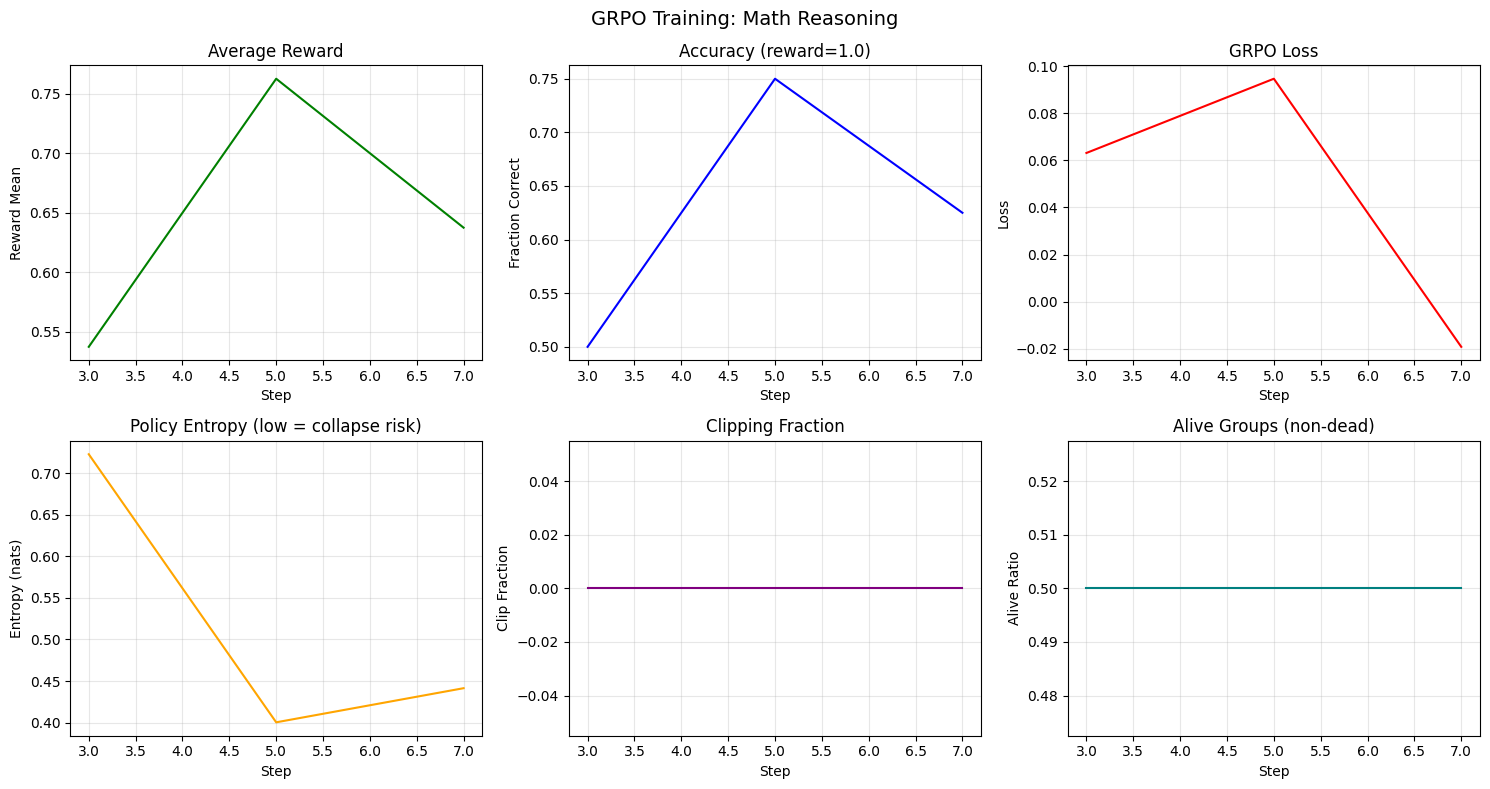

In [ ]:
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16).to(device)
math_dataset = SimpleDataset(MATH_SAMPLES)
math_metrics = train_grpo(
    model, tokenizer, math_dataset, math_reward, math_config, ground_truth_key="answer"
)
plot_training_metrics(math_metrics, title="GRPO Training: Math Reasoning")

# 8.3 Tool calling dataset and training

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  Epoch 0 Step 0: loss=-0.0218  reward=0.29  correct=25%  clip=0.00%  entropy=0.96  alive=1/2  lr=3.33e-06
  Epoch 0 Step 1: loss=0.0102  reward=0.29  correct=12%  clip=0.00%  entropy=0.77  alive=1/2  lr=6.67e-06
  Epoch 0 Step 2: loss=-0.0189  reward=0.26  correct=25%  clip=0.00%  entropy=1.31  alive=1/2  lr=1.00e-05
  Epoch 0 Step 3: loss=-0.2329  reward=0.52  correct=50%  clip=0.00%  entropy=0.71  alive=2/2  lr=1.00e-05
  Step 4: ALL GROUPS DEAD — skipping (reward_mean=0.24)
  Epoch 1 Step 5: loss=-0.0617  reward=0.26  correct=25%  clip=0.00%  entropy=0.95  alive=1/2  lr=6.55e-06
  Step 6: ALL GROUPS DEAD — skipping (reward_mean=0.88)
  Epoch 1 Step 7: loss=0.0297  reward=0.76  correct=75%  clip=0.00%  entropy=0.58  alive=1/2  lr=9.55e-07


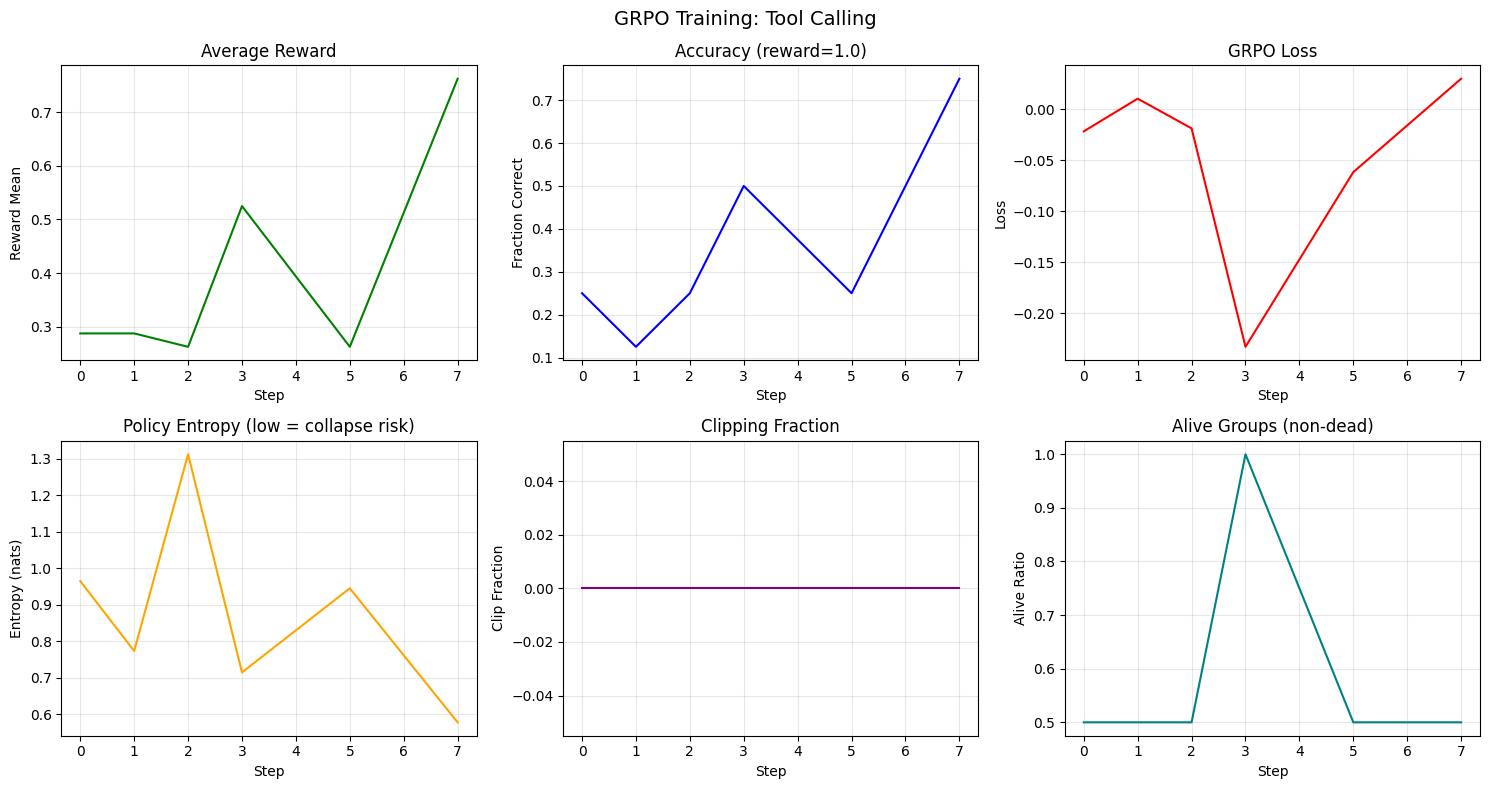

In [ ]:
TOOL_DEFINITIONS = """You have access to the following tools:
[{"name": "get_weather", "description": "Get current weather for a city", "parameters": {"city": {"type": "string", "required": true}}},
 {"name": "calculate", "description": "Evaluate a math expression", "parameters": {"expression": {"type": "string", "required": true}}},
 {"name": "search", "description": "Search the web for information", "parameters": {"query": {"type": "string", "required": true}}}]

Respond with a JSON tool call: {"name": "...", "arguments": {...}}
Only call a tool if needed. Otherwise respond normally."""

TOOL_SAMPLES = [
    {"prompt": f"{TOOL_DEFINITIONS}\n\nUser: What's the weather in Tokyo?",
     "expected": {"name": "get_weather", "arguments": {"city": "Tokyo"}}},
    {"prompt": f"{TOOL_DEFINITIONS}\n\nUser: What is 234 * 567?",
     "expected": {"name": "calculate", "arguments": {"expression": "234 * 567"}}},
    {"prompt": f"{TOOL_DEFINITIONS}\n\nUser: Search for latest AI news",
     "expected": {"name": "search", "arguments": {"query": "latest AI news"}}},
    {"prompt": f"{TOOL_DEFINITIONS}\n\nUser: Weather in London today?",
     "expected": {"name": "get_weather", "arguments": {"city": "London"}}},
    {"prompt": f"{TOOL_DEFINITIONS}\n\nUser: Calculate 15% of 200",
     "expected": {"name": "calculate", "arguments": {"expression": "0.15 * 200"}}},
    {"prompt": f"{TOOL_DEFINITIONS}\n\nUser: Find info about quantum computing",
     "expected": {"name": "search", "arguments": {"query": "quantum computing"}}},
    {"prompt": f"{TOOL_DEFINITIONS}\n\nUser: What's the temperature in Paris?",
     "expected": {"name": "get_weather", "arguments": {"city": "Paris"}}},
    {"prompt": f"{TOOL_DEFINITIONS}\n\nUser: What is the square root of 144?",
     "expected": {"name": "calculate", "arguments": {"expression": "sqrt(144)"}}},
]

# Reset model
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16).to(device)

tool_config = GRPOConfig(
    num_generations=4,
    max_new_tokens=64,         # Tool calls are short
    temperature=0.7,           # Less random for structured output
    top_p=0.90,
    epsilon=0.2,
    mu=1,
    beta=0.0,
    use_reference_model=False,
    loss_type="dapo",
    lr=1e-5,
    batch_size=2,
    grad_accum_steps=1,
    num_epochs=2,
    warmup_steps=3,
    filter_dead_groups=True,
    mask_truncated=True,
)

tool_dataset = SimpleDataset(TOOL_SAMPLES)
tool_metrics = train_grpo(model, tokenizer, tool_dataset, tool_call_reward, tool_config, ground_truth_key="expected")

plot_training_metrics(tool_metrics, title="GRPO Training: Tool Calling")

# 9) Advanced GRPO Improvements (Extension)

The GRPO implementation above already includes many DAPO improvements.
Here we summarize all the variants and when to use each.

**Loss aggregation variants**

| Variant | Formula | Length bias? | When to use |
|---------|---------|-------------|-------------|
| GRPO (original) | $\frac{1}{G} \sum_i \frac{1}{\|o_i\|} \sum_t l_t$ | Yes — shorter responses get stronger gradients | Baseline comparison |
| Dr-GRPO | $\frac{1}{LG} \sum_i \sum_t l_t$ where $L$ = max_completion_length | No | When response lengths vary a lot |
| DAPO | $\frac{1}{\sum_i \|o_i\|} \sum_i \sum_t l_t$ (total active tokens) | No | Default recommendation |

**Clipping variants**

| Variant | Clipping range | Effect |
|---------|---------------|--------|
| Standard | $[1-\epsilon, 1+\epsilon]$ | Symmetric — equal constraint on reinforcement and discouragement |
| Clip-Higher (DAPO) | $[1-\epsilon, 1+\delta]$ where $\delta > \epsilon$ | Asymmetric — allows more aggressive reinforcement of good responses, helps prevent entropy collapse |

**Other DAPO improvements** (all implemented in our training loop):

| Technique | What it does | Config flag |
|-----------|-------------|-------------|
| Dynamic sampling | Skip groups where all rewards are identical | `filter_dead_groups=True` |
| Truncation masking | Exclude responses that hit max_new_tokens without EOS | `mask_truncated=True` |
| Token-level loss | Default DAPO aggregation treats all tokens equally | `loss_type="dapo"` |
| No KL divergence | Clipping is sufficient to constrain the policy | `beta=0.0` |

---

**Monitoring checklist**

| Metric | Healthy range | Problem if |
|--------|-------------|------------|
| reward_mean | Increasing over time | Flat or decreasing |
| entropy | Stays > 1.0 nats | Drops below 0.5 (entropy collapse) |
| clip_fraction | 0.05 – 0.30 | Near 0 (no learning) or > 0.5 (unstable) |
| alive_groups | > 50% of total | Near 0 (all dead — model is too good or too bad for this data) |
| approx_kl | < 0.1 | > 0.2 (policy changing too fast, reduce LR or increase clipping) |

If **entropy collapses**, try: higher temperature, asymmetric clipping (epsilon_high),
or adding a small entropy bonus to the loss.

If **all groups are dead** with reward=0, the problems are too hard.
Start with easier data or use SFT warmup first.

If **all groups are dead** with reward=1, the problems are too easy.
Switch to harder data — the model has learned everything here.

**Key takeaways**

1. **The reward function defines the capability.** Same GRPO algorithm,
   different reward → different skill (reasoning, tool calling, coding).

2. **The model generates its own training data.** This is fundamentally
   different from DPO/SFT and allows the model to discover solutions
   that weren't in any dataset.

3. **Advantages must have variance.** Dead groups (all same reward) produce
   no gradient. Monitor alive_groups and adjust data difficulty accordingly.

4. **Entropy is your canary.** If it drops too low, the model is collapsing.
   Use asymmetric clipping, higher temperature, or entropy bonus.

5. **Multi-iteration updates** ($\mu > 1$) amortize the expensive generation
   cost. But watch approx_kl — if it gets too high, the policy has drifted
   too far and the importance weights become unreliable.

6. **For production, use TRL's GRPOTrainer, Unsloth, or NeMo-RL.** They handle
   distributed generation, efficient batching, and memory optimization.
   Our from-scratch implementation is for understanding, not deployment.
